# MGMT298D: Science and Strategy of AI
### Week 1 - Linear Regression with Feature Engineering
### Application: sales Forecasting at H&M

## Import Libraries and Data

In [1]:
# Import necessary libraries for data manipulation, machine learning, and metrics.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error

df = pd.read_csv("https://raw.githubusercontent.com/ucla-anderson-SSAI/SSAI/refs/heads/main/HMData.csv")

## Select a Product Category and Visualize Sales

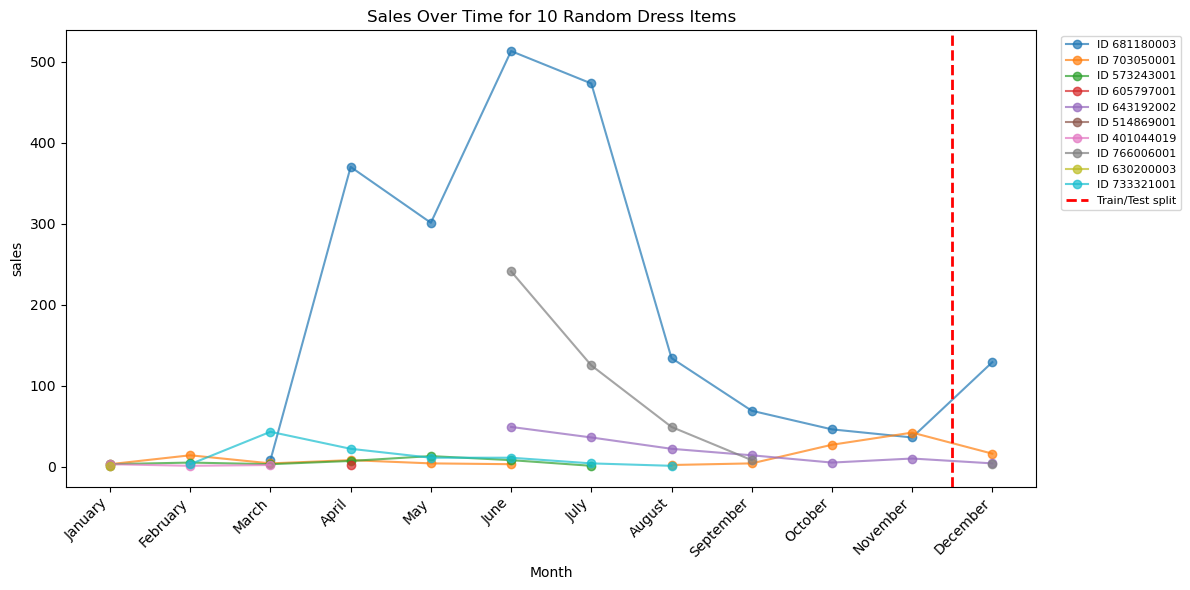

In [5]:
# AVAILABLE CATEGORIES:
# Bag, Belt, Blazer, Blouse, Bodysuit, Boots, Cardigan, Coat, Costumes, Dress, Hat/beanie, Hat/brim, 
# Hoodie, Jacket, Jumpsuit/Playsuit, Leggings/Tights, Sandals, Shirt, Shorts, Skirt, Sneakers, Socks, Sunglasses, Sweater, 
# Swimsuit, T-shirt, Top, Trousers, Vest top
SELECTED_PRODUCT = "Dress"
df_sub = df[df["name"] == SELECTED_PRODUCT].copy()
month_cols = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

# Create month_num column
df_sub["month_num"] = df_sub[month_cols].idxmax(axis=1).map({m: i+1 for i, m in enumerate(month_cols)})
months_sub = np.sort(df_sub["month_num"].unique())

# Visualize sales for 10 random products over time
fig, ax = plt.subplots(figsize=(12, 6))
np.random.seed(42)
sample_ids = np.random.choice(df_sub["id"].unique(), size=10, replace=False)
for pid in sample_ids:
    product_data = df_sub[df_sub["id"] == pid]
    monthly_sales = []
    for month in month_cols:
        sales = product_data[product_data[month] == 1]["sales"].values
        monthly_sales.append(sales[0] if len(sales) > 0 else np.nan)
    ax.plot(range(1, 13), monthly_sales, marker="o", alpha=0.7, label=f"ID {pid}")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_cols, rotation=45, ha="right")
ax.axvline(11.5, color="red", linestyle="--", linewidth=2, label="Train/Test split")
ax.set_xlabel("Month")
ax.set_ylabel("sales")
ax.set_title(f"Sales Over Time for 10 Random {SELECTED_PRODUCT} Items")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Model A: Price + Month Only

In [7]:
# Initial train/test split for Model A
train = df_sub[df_sub["month_num"] < months_sub[-1]].copy()
test  = df_sub[df_sub["month_num"] == months_sub[-1]].copy()
print("[INFO] train rows:", len(train), "| test rows:", len(test))

modelA_num = ["price"]
train_A = train[modelA_num].copy()
test_A  = test[modelA_num].copy()

scaler_A = StandardScaler()
train_A[modelA_num] = scaler_A.fit_transform(train_A[modelA_num])
test_A[modelA_num]  = scaler_A.transform(test_A[modelA_num])

X_tr, X_te = train_A.values, test_A.values
y_tr, y_te = train["sales"], test["sales"]

lasso_A = LassoCV(cv=100, random_state=0).fit(X_tr, y_tr)
pred_A = lasso_A.predict(X_te)

print(f"Model A — Mean absolute error = {mean_absolute_error(y_te, pred_A):.2f}")

[INFO] train rows: 1914 | test rows: 174
Model A — Mean absolute error = 57.79


## Feature Engineering: Lag Features

In [9]:
# Create lag and temporal features
for i in range(1, 4):
    df_sub[f"lag_m{i}"] = df_sub.groupby("id")["sales"].shift(i)
df_sub["ma_3"] = df_sub.groupby("id")["sales"].shift(1).rolling(3, min_periods=1).mean().values
df_sub["price_change"] = df_sub.groupby("id")["price"].pct_change()
df_sub[["lag_m1", "lag_m2", "lag_m3", "ma_3", "price_change"]] = df_sub[["lag_m1", "lag_m2", "lag_m3", "ma_3", "price_change"]].fillna(0)

# Re-split after feature engineering (used by Models B and C)
train = df_sub[df_sub["month_num"] < months_sub[-1]].copy()
test  = df_sub[df_sub["month_num"] == months_sub[-1]].copy()
y_tr, y_te = train["sales"], test["sales"]

## Model B: Add Last Month's Sales

In [11]:
modelB_num = ["price", "lag_m1"]
cols_B = modelB_num

scaler_B = StandardScaler()
X_tr_B = train[cols_B].copy()
X_te_B = test[cols_B].copy()

X_tr_B[modelB_num] = scaler_B.fit_transform(X_tr_B[modelB_num])
X_te_B[modelB_num] = scaler_B.transform(X_te_B[modelB_num])

lasso_B = LassoCV(cv=100, random_state=0).fit(X_tr_B, y_tr)
pred_B = lasso_B.predict(X_te_B)
print(f"Model B — Mean absolute error = {mean_absolute_error(y_te, pred_B):.2f}")

Model B — Mean absolute error = 29.30


## Model C: Add All Temporal Features

In [13]:
modelC_num = ["price", "price_change", "lag_m1", "lag_m2", "lag_m3", "ma_3"]
cols_C = modelC_num

scaler_C = StandardScaler()
X_tr_C = train[cols_C].copy()
X_te_C = test[cols_C].copy()

X_tr_C[modelC_num] = scaler_C.fit_transform(X_tr_C[modelC_num])
X_te_C[modelC_num] = scaler_C.transform(X_te_C[modelC_num])

lasso_C = LassoCV(cv=100, random_state=0).fit(X_tr_C, y_tr)
pred_C = lasso_C.predict(X_te_C)
print(f"Model C — Mean absolute error = {mean_absolute_error(y_te, pred_C):.2f}")

Model C — Mean absolute error = 26.94


## Model Comparison Visualization

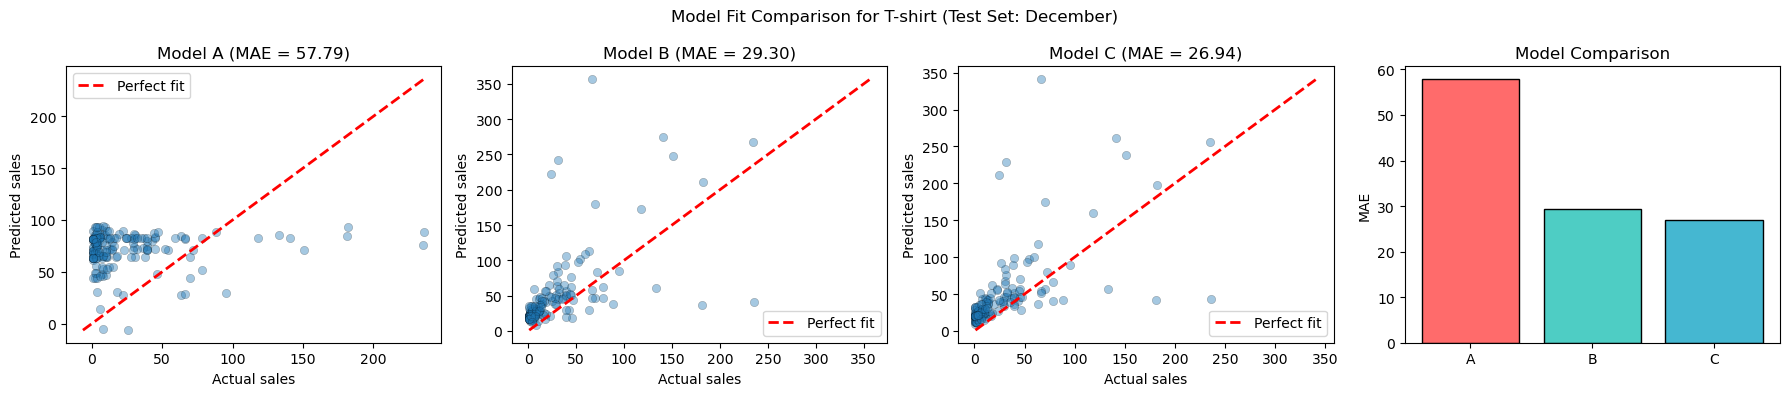

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

models = [("Model A", pred_A), ("Model B", pred_B), ("Model C", pred_C)]

for ax, (name, pred) in zip(axes[:3], models):
    mae = mean_absolute_error(y_te, pred)
    ax.scatter(y_te, pred, alpha=0.4, edgecolor="k", linewidth=0.3)
    lims = [min(y_te.min(), pred.min()), max(y_te.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=2, label="Perfect fit")
    ax.set_xlabel("Actual sales")
    ax.set_ylabel("Predicted sales")
    ax.set_title(f"{name} (MAE = {mae:.2f})")
    ax.legend()

# Bar plot
maes = [mean_absolute_error(y_te, p) for _, p in models]
axes[3].bar(["A", "B", "C"], maes, color=["#ff6b6b", "#4ecdc4", "#45b7d1"], edgecolor="k")
axes[3].set_ylabel("MAE")
axes[3].set_title("Model Comparison")

fig.suptitle(f"Model Fit Comparison for {SELECTED_PRODUCT} (Test Set: December)", fontsize=12)
plt.tight_layout()
plt.show()